In [ ]:
!pip install -q torch scikit-learn pandas numpy matplotlib seaborn

Device: cuda
EBAMTN-STL | 24-Hour Forecasting | Delhi
Targets: ['pm25', 'no2', 'ozone', 'co']
Rows -> Train:52584  Val:1416  Test:744
Sequences -> Train:52393  Val:1225  Test:553
X shape: (52393, 168, 14)  y shape: (52393, 24, 4)

Training EBAMTN-STL-PM25 (24h ahead) ...
  Early stop @ ep 14
  PM25 -> MAE=25.718  RMSE=33.229  R2=0.2300

Training EBAMTN-STL-NO2 (24h ahead) ...
  Ep  20  train=0.00398  val=0.00289
  Early stop @ ep 30
  NO2 -> MAE=6.758  RMSE=8.855  R2=0.4220

Training EBAMTN-STL-OZONE (24h ahead) ...
  Ep  20  train=0.00536  val=0.00277
  Early stop @ ep 31
  OZONE -> MAE=7.334  RMSE=9.761  R2=0.8220

Training EBAMTN-STL-CO (24h ahead) ...
  Early stop @ ep 12
  CO -> MAE=0.265  RMSE=0.349  R2=0.2684


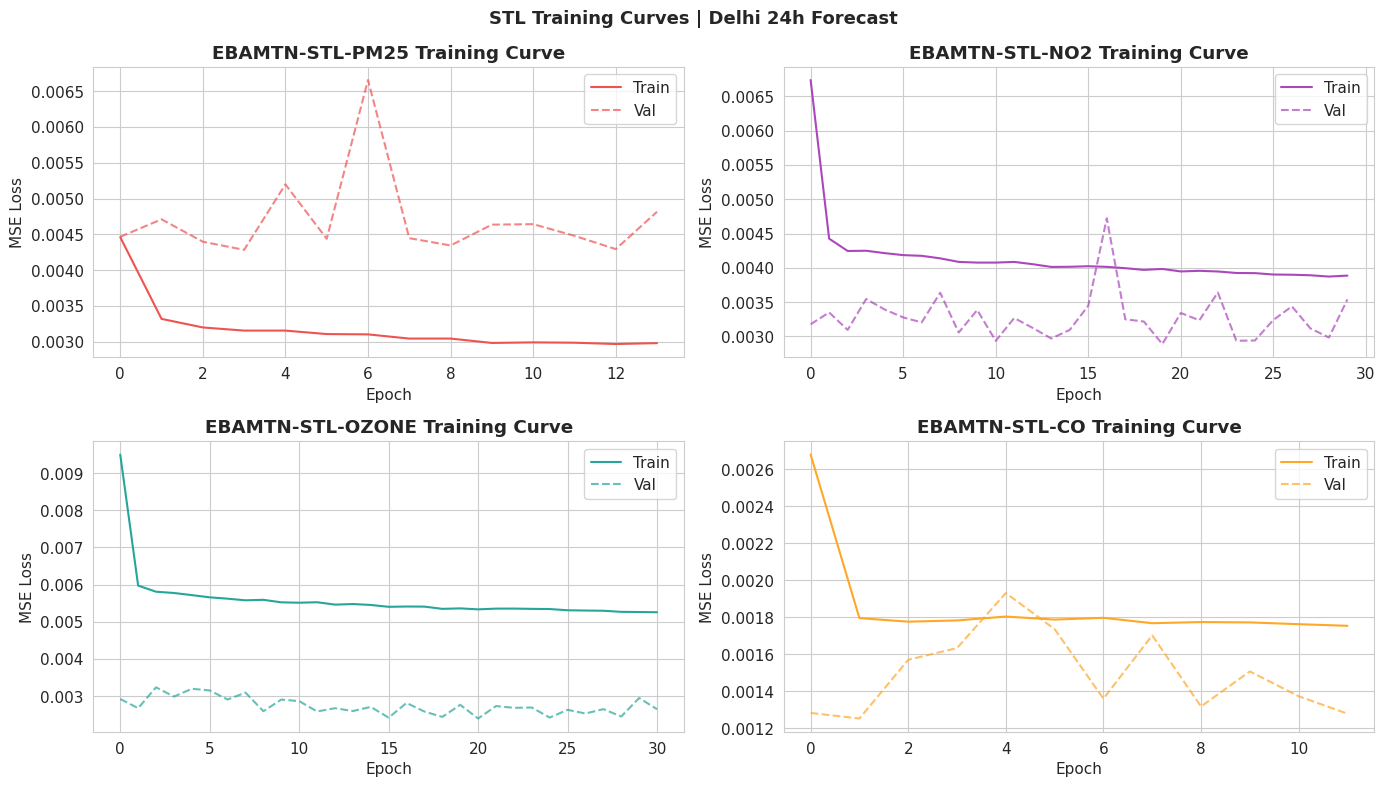

Saved: stl_training_curves.png


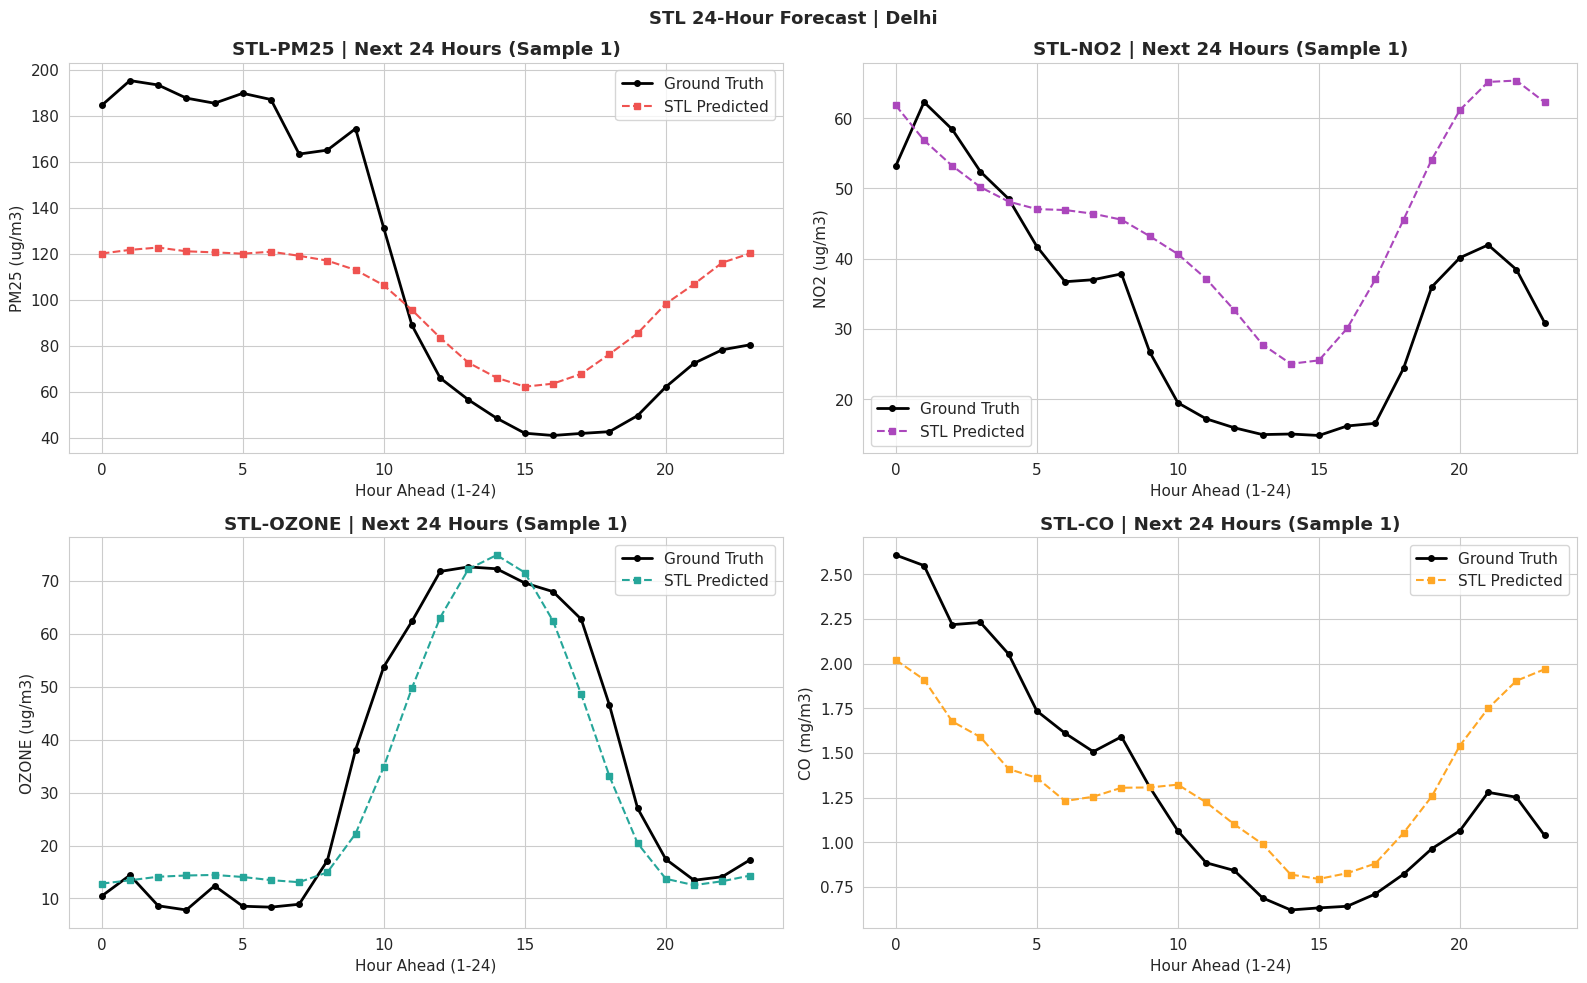

Saved: stl_24h_sample.png


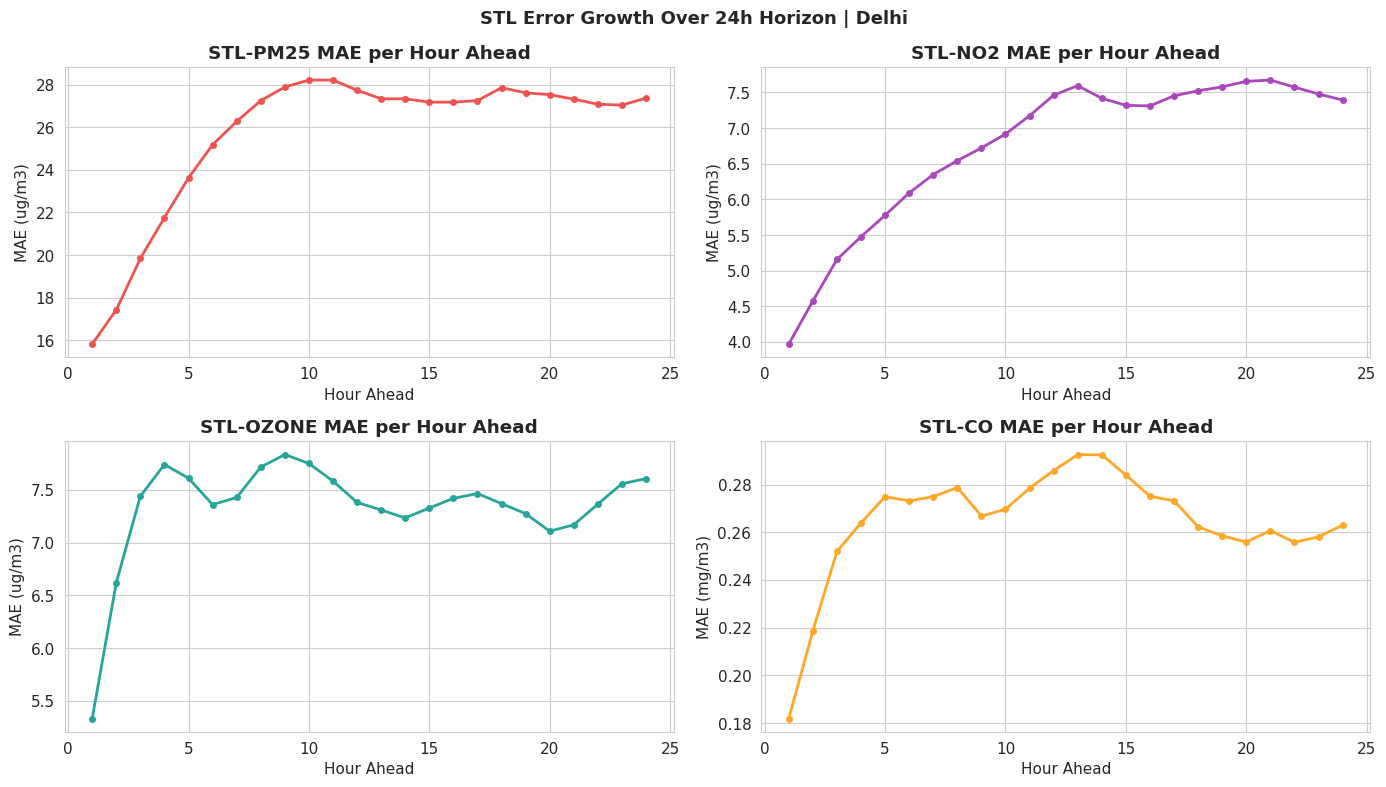

Saved: stl_mae_per_hour.png

STL done. Run Cell 2 for MTL.


In [ ]:


import random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

HORIZON = 24   # predict next 24 hours

# Four target pollutants for MTL vs STL comparison
TARGET_COLS = ["pm25", "no2", "ozone", "co"]

CFG = dict(
    train_path    = "Train_data.csv",
    val_path      = "Validation_data.csv",
    test_path     = "Test_data.csv",
    feature_cols  = ["pm25","pm10","no","nh3","no2","nox",
                     "so2","co","ozone","bp","wind_speed",
                     "air_temp","humidity","rainfall"],
    target_cols   = TARGET_COLS,
    window_size   = 168,   # 1 week look-back
    horizon       = HORIZON,
    batch_size    = 128,
    lr            = 1e-3,
    weight_decay  = 1e-4,
    epochs        = 100,
    patience      = 10,
    noise_factor  = 0.05,
    grad_clip     = 1.0,
    alpha         = 0.25,   # equal weight per task (1/4)
    tcn_channels  = [32, 64, 128],
    bilstm_hidden = 64,
    bilstm_layers = 2,
    num_heads     = 4,
    fusion_dim    = 128,
    dropout       = 0.1,
)


def _sort(df):
    col = "from_date" if "from_date" in df.columns else "Date"
    df[col] = pd.to_datetime(df[col])
    return df.sort_values(col).reset_index(drop=True)

def load_splits(cfg):
    cols = cfg["feature_cols"]
    dfs  = [_sort(pd.read_csv(p))[cols].dropna().reset_index(drop=True)
            for p in (cfg["train_path"], cfg["val_path"], cfg["test_path"])]
    scalers = {}
    scaled  = [np.zeros((len(df), len(cols)), dtype=np.float32) for df in dfs]
    for i, col in enumerate(cols):
        sc = MinMaxScaler()
        scaled[0][:,i] = sc.fit_transform(dfs[0][[col]]).flatten()
        scaled[1][:,i] = sc.transform(dfs[1][[col]]).flatten()
        scaled[2][:,i] = sc.transform(dfs[2][[col]]).flatten()
        scalers[col]   = sc
    print(f"Rows -> Train:{len(scaled[0])}  Val:{len(scaled[1])}  Test:{len(scaled[2])}")
    return scaled[0], scaled[1], scaled[2], scalers, cols

def make_sequences(data, window, horizon, tgt_idx):
    """
    Input:  past `window` hours         shape (window, n_features)
    Target: NEXT `horizon` hours        shape (horizon, n_targets)
    """
    X, y = [], []
    for i in range(window, len(data) - horizon + 1):
        X.append(data[i - window: i])               # (168, 14)
        y.append(data[i: i + horizon][:, tgt_idx])  # (24, 4)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

class AQDataset(Dataset):
    def __init__(self, X, y, noise=0.0):
        self.X=torch.tensor(X); self.y=torch.tensor(y); self.noise=noise
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        x = self.X[idx]
        if self.noise > 0: x = x + self.noise*torch.randn_like(x)
        return x, self.y[idx]

def make_loaders(X_tr,y_tr,X_va,y_va,X_te,y_te,cfg):
    kw = dict(batch_size=cfg["batch_size"], num_workers=0, pin_memory=True)
    return (DataLoader(AQDataset(X_tr,y_tr,cfg["noise_factor"]),shuffle=True, **kw),
            DataLoader(AQDataset(X_va,y_va),                    shuffle=False,**kw),
            DataLoader(AQDataset(X_te,y_te),                    shuffle=False,**kw))


class MultiScaleTCN(nn.Module):
    def __init__(self, in_ch, branch_ch=(32,64,128), dropout=0.1):
        super().__init__()
        branch_ch = list(branch_ch)
        self.branches = nn.ModuleList([
            nn.Sequential(nn.Conv1d(in_ch,oc,k,padding=k//2),
                          nn.BatchNorm1d(oc),nn.ReLU(),nn.Dropout(dropout))
            for k,oc in zip([3,5,7],branch_ch)])
        self.total_ch   = sum(branch_ch)
        self.score_fcs  = nn.ModuleList([nn.Linear(oc,1) for oc in branch_ch])
        self.proj_convs = nn.ModuleList([nn.Conv1d(oc,self.total_ch,1) for oc in branch_ch])
        ch = self.total_ch
        self.dil_layers = nn.ModuleList([
            nn.Sequential(nn.Conv1d(ch,ch,3,padding=2**l,dilation=2**l),
                          nn.BatchNorm1d(ch),nn.ReLU(),nn.Dropout(dropout))
            for l in range(4)])
        self.skip_convs = nn.ModuleList([nn.Conv1d(ch,ch,1) for _ in range(4)])

    def forward(self, x):
        x     = x.permute(0,2,1)
        bouts = [b(x) for b in self.branches]
        scores  = torch.cat([fc(bo.mean(-1)) for fc,bo in zip(self.score_fcs,bouts)],dim=-1)
        weights = torch.softmax(scores,dim=-1)
        projs   = [pc(bo) for pc,bo in zip(self.proj_convs,bouts)]
        fused   = sum(weights[:,i:i+1].unsqueeze(-1)*projs[i] for i in range(len(self.branches)))
        h,skip_sum = fused,0
        for dl,sk in zip(self.dil_layers,self.skip_convs):
            h=dl(h)+h; skip_sum=skip_sum+sk(h)
        return skip_sum.permute(0,2,1)   # (B, T, total_ch)

class BiLSTMAttention(nn.Module):
    def __init__(self, in_dim, hidden=64, layers=2, heads=4, dropout=0.1):
        super().__init__()
        self.bilstm = nn.LSTM(in_dim,hidden,layers,batch_first=True,
                              bidirectional=True,dropout=dropout if layers>1 else 0)
        self.attn = nn.MultiheadAttention(hidden*2,heads,dropout=dropout,batch_first=True)
        self.gate = nn.Linear(hidden*4,hidden*2)
        self.proj = nn.Linear(hidden*2,hidden*2)
    def forward(self, x):
        H,_ = self.bilstm(x); A,_ = self.attn(H,H,H)
        G   = torch.sigmoid(self.gate(torch.cat([H,A],dim=-1)))
        return self.proj(G*H+(1-G)*A)   # (B, T, 2H)

class GatedFusion(nn.Module):
    def __init__(self, tcn_dim, lstm_dim, fusion_dim, dropout=0.1):
        super().__init__()
        self.fc  = nn.Sequential(nn.Linear(tcn_dim+lstm_dim,fusion_dim),
                                 nn.ReLU(),nn.Dropout(dropout))
        self.tam = nn.Linear(fusion_dim,1)
    def forward(self, f_tcn, f_lstm):
        h = self.fc(torch.cat([f_tcn,f_lstm],dim=-1))   # (B, T, fusion)
        w = torch.sigmoid(self.tam(h))                   # (B, T, 1)
        return (h*w)[:,-1,:]                             # (B, fusion) — last timestep


class STLHead(nn.Module):
    def __init__(self, in_dim, horizon, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, horizon)   # outputs all 24 hours at once
        )
    def forward(self, x): return self.net(x)   # (B, horizon)


class EBAMTN_STL(nn.Module):
    """Single-Task: same backbone, one head predicting 24h for ONE pollutant."""
    def __init__(self, n_feat, cfg):
        super().__init__()
        self.tcn    = MultiScaleTCN(n_feat, cfg["tcn_channels"], cfg["dropout"])
        self.bilstm = BiLSTMAttention(n_feat, cfg["bilstm_hidden"],
                                      cfg["bilstm_layers"], cfg["num_heads"], cfg["dropout"])
        self.fusion = GatedFusion(sum(cfg["tcn_channels"]), cfg["bilstm_hidden"]*2,
                                  cfg["fusion_dim"], cfg["dropout"])
        self.head   = STLHead(cfg["fusion_dim"], cfg["horizon"])

    def forward(self, x):
        return self.head(self.fusion(self.tcn(x), self.bilstm(x)))  # (B, 24)


def train_stl(model, tr_loader, va_loader, cfg, target_idx):
    """target_idx: index within TARGET_COLS (0=PM2.5, 1=NO2, 2=Ozone, 3=CO)"""
    opt = optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])
    mse = nn.MSELoss()
    best_val,best_w,wait = np.inf,None,0
    tr_hist,va_hist = [],[]

    for ep in range(1, cfg["epochs"]+1):
        model.train(); tl=0.0
        for xb,yb in tr_loader:
            xb,yb = xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad()
            pred = model(xb)                      # (B, 24)
            true = yb[:,:,target_idx]             # (B, 24) — all 24 hours
            loss = mse(pred, true)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            opt.step(); tl+=loss.item()*len(xb)
        sch.step(); tl/=len(tr_loader.dataset)

        model.eval(); vl=0.0
        with torch.no_grad():
            for xb,yb in va_loader:
                xb,yb=xb.to(DEVICE),yb.to(DEVICE)
                vl+=mse(model(xb), yb[:,:,target_idx]).item()*len(xb)
        vl/=len(va_loader.dataset)
        tr_hist.append(tl); va_hist.append(vl)

        if vl<best_val: best_val,best_w,wait=vl,deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=cfg["patience"]: print(f"  Early stop @ ep {ep}"); break
        if ep%20==0: print(f"  Ep {ep:3d}  train={tl:.5f}  val={vl:.5f}")

    model.load_state_dict(best_w)
    return model, tr_hist, va_hist

@torch.no_grad()
def predict_stl(model, loader, target_idx):
    model.eval(); preds,trues=[],[]
    for xb,yb in loader:
        preds.append(model(xb.to(DEVICE)).cpu().numpy())       # (B, 24)
        trues.append(yb[:,:,target_idx].numpy())               # (B, 24)
    return np.concatenate(preds), np.concatenate(trues)        # (N, 24)

def inv_horizon(arr, sc):
    """Inverse transform (N, 24) scaled array."""
    N, H = arr.shape
    return sc.inverse_transform(arr.reshape(-1,1)).reshape(N, H)

def get_metrics(true, pred):
    """Metrics averaged across all 24 horizons."""
    true_flat = true.flatten(); pred_flat = pred.flatten()
    return dict(MAE  = mean_absolute_error(true_flat, pred_flat),
                RMSE = np.sqrt(mean_squared_error(true_flat, pred_flat)),
                R2   = r2_score(true_flat, pred_flat))

def get_metrics_per_hour(true, pred):
    """Returns MAE per horizon step (24 values)."""
    return [mean_absolute_error(true[:,h], pred[:,h]) for h in range(true.shape[1])]


print("="*60)
print("EBAMTN-STL | 24-Hour Forecasting | Delhi")
print(f"Targets: {TARGET_COLS}")
print("="*60)

tr_d,va_d,te_d,scalers,feat_cols = load_splits(CFG)
tgt_idx = [feat_cols.index(c) for c in CFG["target_cols"]]
n_feat  = len(feat_cols)

X_tr,y_tr = make_sequences(tr_d, CFG["window_size"], CFG["horizon"], tgt_idx)
X_va,y_va = make_sequences(va_d, CFG["window_size"], CFG["horizon"], tgt_idx)
X_te,y_te = make_sequences(te_d, CFG["window_size"], CFG["horizon"], tgt_idx)
print(f"Sequences -> Train:{len(X_tr)}  Val:{len(X_va)}  Test:{len(X_te)}")
print(f"X shape: {X_tr.shape}  y shape: {y_tr.shape}")
# y shape will be (N, 24, 4) — 24 hours, 4 targets

tr_loader,va_loader,te_loader = make_loaders(X_tr,y_tr,X_va,y_va,X_te,y_te,CFG)

stl_results={}; stl_loss_curves={}; stl_preds={}

# Colour palette for 4 STL models
STL_COLORS = {
    "PM25":  "#EF5350",
    "NO2":   "#AB47BC",
    "OZONE": "#26A69A",
    "CO":    "#FFA726",
}
MTL_COLOR = "#1E88E5"


for i, (col, label, color) in enumerate(zip(
        TARGET_COLS,
        ["PM25", "NO2", "OZONE", "CO"],
        [STL_COLORS["PM25"], STL_COLORS["NO2"], STL_COLORS["OZONE"], STL_COLORS["CO"]])):

    model_name = f"EBAMTN-STL-{label}"
    print(f"\nTraining {model_name} (24h ahead) ...")
    model = EBAMTN_STL(n_feat, CFG).to(DEVICE)
    model, tl, vl = train_stl(model, tr_loader, va_loader, CFG, target_idx=i)
    p, t = predict_stl(model, te_loader, target_idx=i)   # (N, 24)
    p_r  = inv_horizon(p, scalers[col])
    t_r  = inv_horizon(t, scalers[col])
    m    = get_metrics(t_r, p_r)

    stl_results[model_name]     = {col: m}
    stl_loss_curves[model_name] = {"train": tl, "val": vl, "color": color}
    stl_preds[model_name]       = {"pred": p_r, "true": t_r, "col": col, "label": label}
    print(f"  {col.upper()} -> MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  R2={m['R2']:.4f}")


sns.set_style("whitegrid"); plt.rcParams.update({"font.size":11})

# Plot 1: training curves (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for ax, (name, curves) in zip(axes, stl_loss_curves.items()):
    c = curves["color"]
    ax.plot(curves["train"], label="Train", color=c)
    ax.plot(curves["val"],   label="Val",   color=c, ls="--", alpha=0.7)
    ax.set_title(name + " Training Curve", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.legend()
plt.suptitle("STL Training Curves | Delhi 24h Forecast", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("stl_training_curves.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: stl_training_curves.png")

# Plot 2: predicted vs true for first test sample (2x2 grid)
UNITS = {"pm25": "ug/m3", "no2": "ug/m3", "ozone": "ug/m3", "co": "mg/m3"}
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for ax, (name, pdata) in zip(axes, stl_preds.items()):
    color = STL_COLORS[pdata["label"]]
    ax.plot(pdata["true"][0], color="black", lw=2, label="Ground Truth", marker="o", ms=4)
    ax.plot(pdata["pred"][0], color=color,   lw=1.5, ls="--", label="STL Predicted", marker="s", ms=4)
    ax.set_title(f"STL-{pdata['label']} | Next 24 Hours (Sample 1)", fontweight="bold")
    ax.set_xlabel("Hour Ahead (1-24)")
    ax.set_ylabel(f"{pdata['col'].upper()} ({UNITS[pdata['col']]})")
    ax.legend()
plt.suptitle("STL 24-Hour Forecast | Delhi", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("stl_24h_sample.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: stl_24h_sample.png")

# Plot 3: MAE per horizon step (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for ax, (name, pdata) in zip(axes, stl_preds.items()):
    color = STL_COLORS[pdata["label"]]
    mae_h = get_metrics_per_hour(pdata["true"], pdata["pred"])
    ax.plot(range(1, 25), mae_h, color=color, lw=2, marker="o", ms=4)
    ax.set_title(f"STL-{pdata['label']} MAE per Hour Ahead", fontweight="bold")
    ax.set_xlabel("Hour Ahead")
    ax.set_ylabel(f"MAE ({UNITS[pdata['col']]})")
plt.suptitle("STL Error Growth Over 24h Horizon | Delhi", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("stl_mae_per_hour.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: stl_mae_per_hour.png")

print("\nSTL done. Run Cell 2 for MTL.")


EBAMTN-MTL | 24-Hour Forecasting | Delhi
Targets: ['pm25', 'no2', 'ozone', 'co']

Training EBAMTN-MTL (PM2.5 + NO2 + Ozone + CO jointly, 24h ahead) ...


MTL Training:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stop @ ep 19
  PM25 -> MAE=22.793  RMSE=30.394  R2=0.3558
  NO2 -> MAE=8.174  RMSE=10.570  R2=0.1764
  OZONE -> MAE=8.368  RMSE=10.828  R2=0.7810
  CO -> MAE=0.248  RMSE=0.334  R2=0.3304

Model                       PM25 MAE  PM25 RMSE  PM25 R2   NO2 MAE   NO2 RMSE   NO2 R2 OZONE MAE OZONE RMSE OZONE R2    CO MAE    CO RMSE    CO R2
------------------------------------------------------------------------------------------
EBAMTN-STL-PM25               25.718     33.229   0.2300       ---        ---      ---       ---        ---      ---       ---        ---      ---
EBAMTN-STL-NO2                   ---        ---      ---     6.758      8.855   0.4220       ---        ---      ---       ---        ---      ---
EBAMTN-STL-OZONE                 ---        ---      ---       ---        ---      ---     7.334      9.761   0.8220       ---        ---      ---
EBAMTN-STL-CO                    ---        ---      ---       ---        ---      ---       ---        ---      ---     0.26

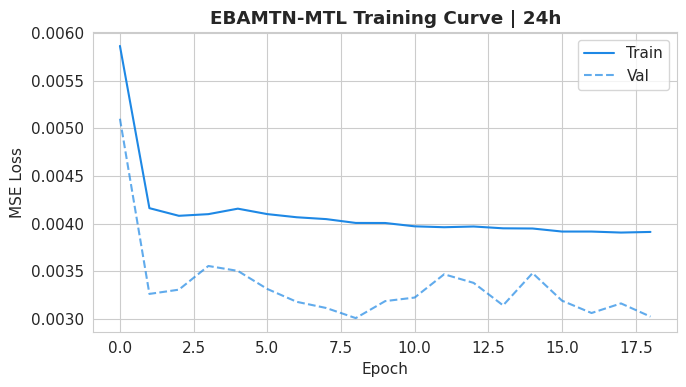

Saved: mtl_training_curve.png


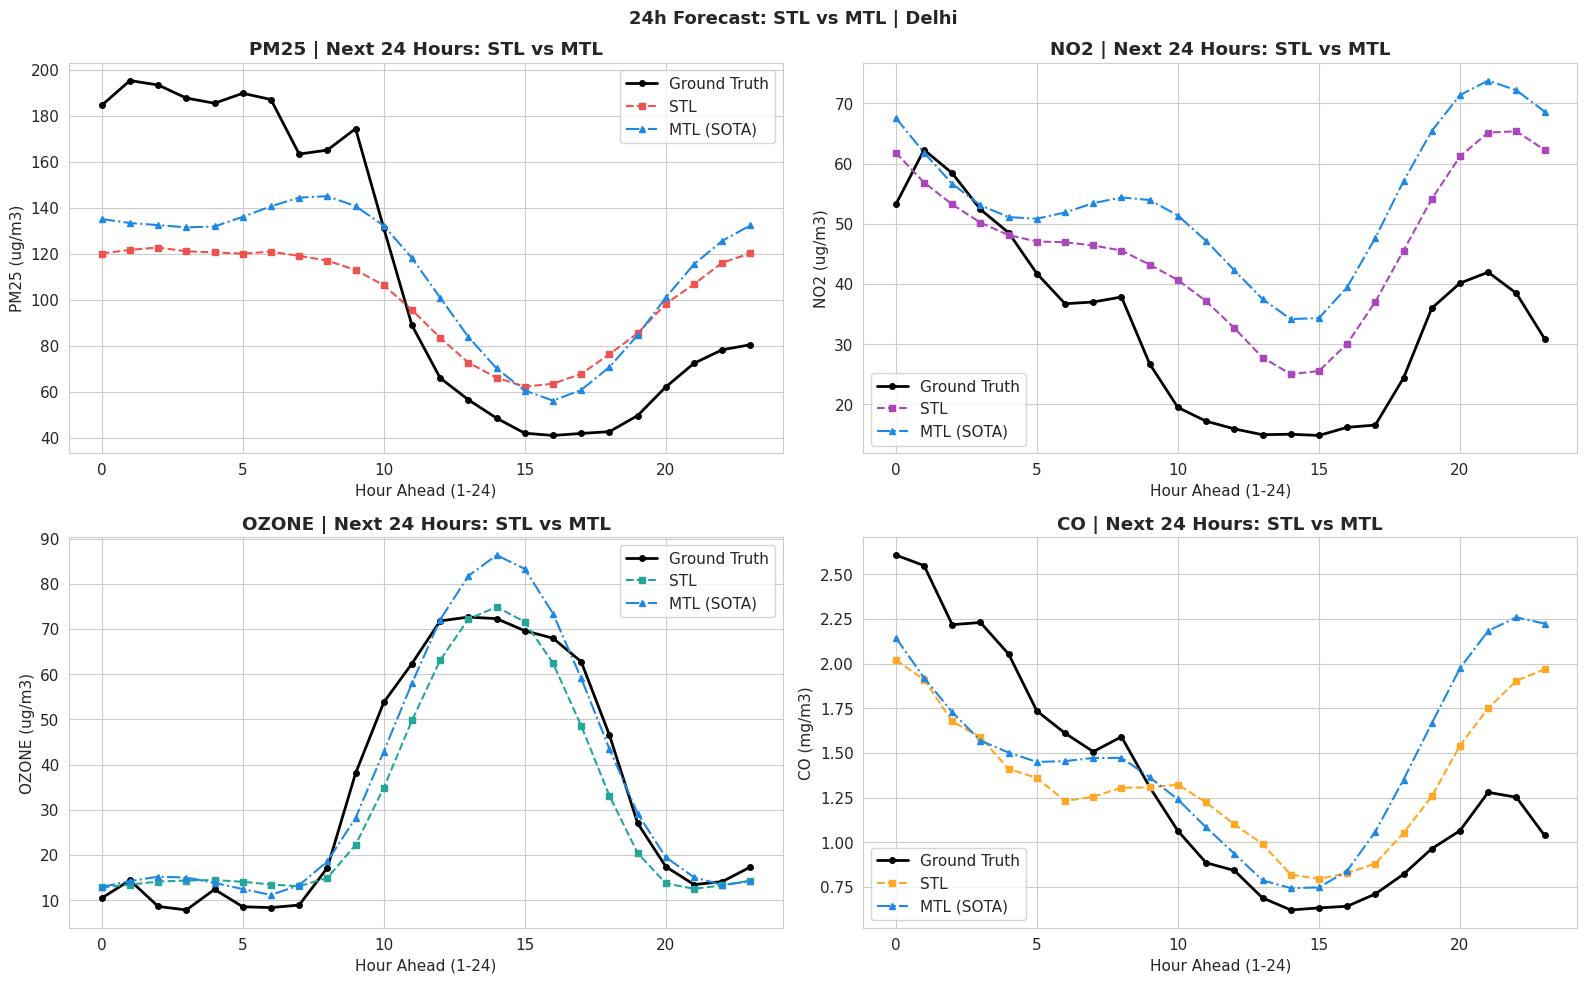

Saved: mtl_vs_stl_24h_sample.png


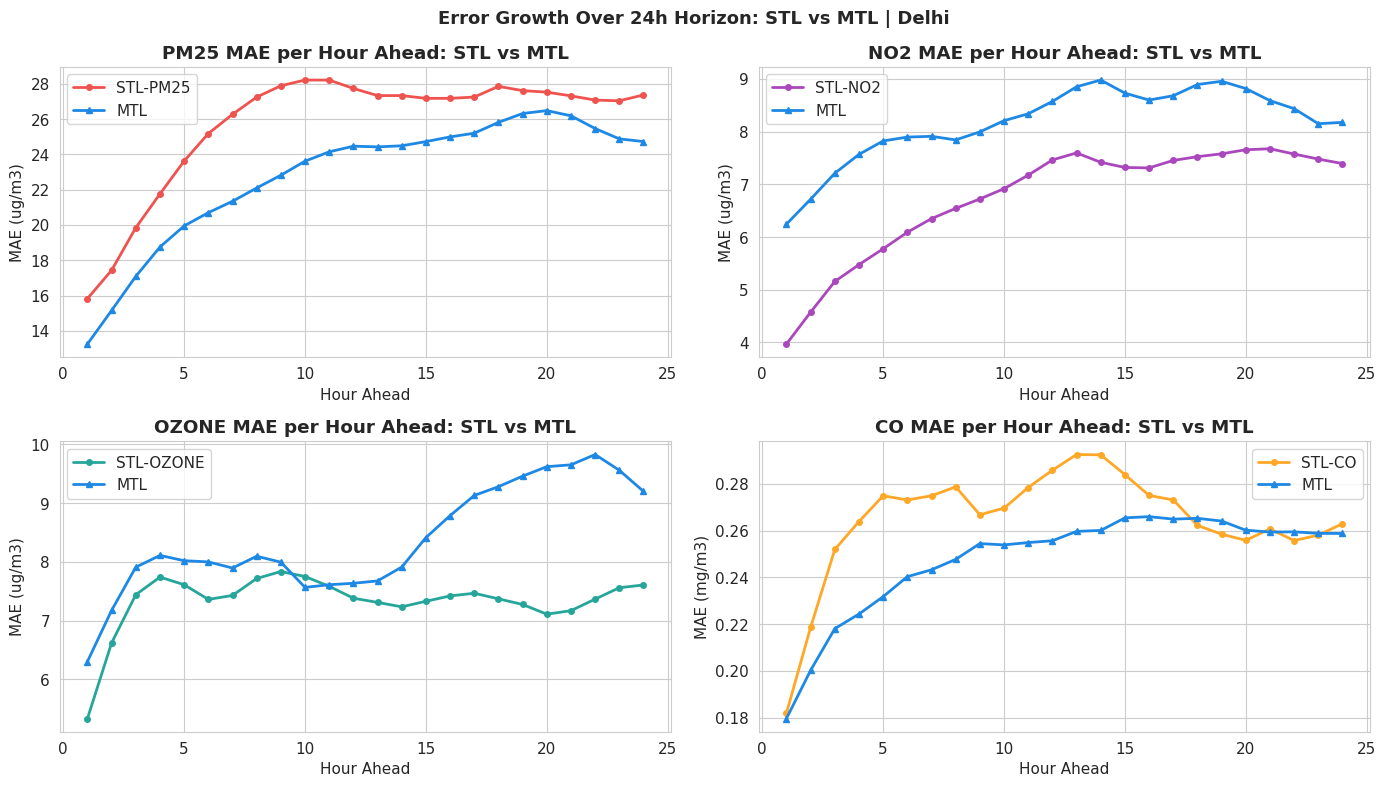

Saved: mae_per_hour_comparison.png


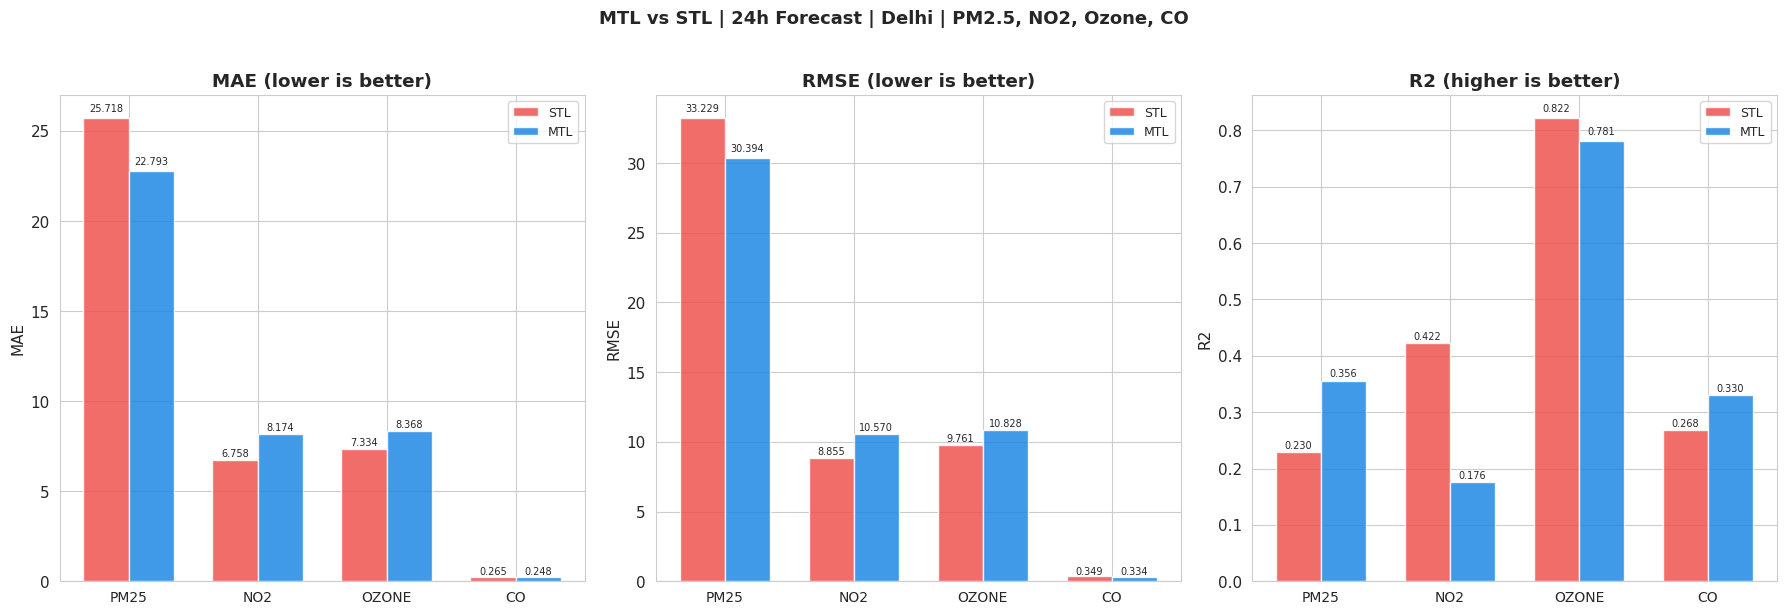

Saved: mtl_vs_stl_metrics.png


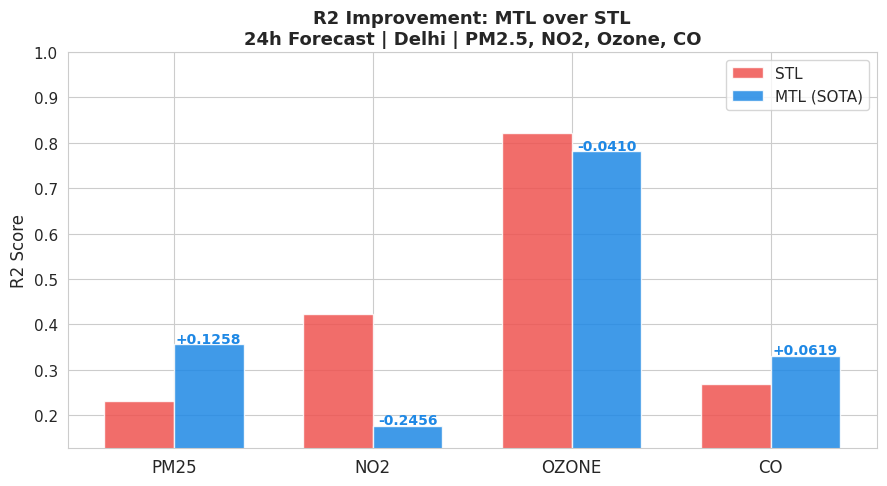

Saved: r2_improvement.png

All done! MTL vs STL 24h comparison complete for PM2.5, NO2, Ozone, CO.


In [ ]:


from tqdm.auto import tqdm


class MTLHead(nn.Module):
    def __init__(self, in_dim, horizon, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, horizon)   # 24 outputs
        )
    def forward(self, x): return self.net(x)   # (B, 24)


class EBAMTN_MTL(nn.Module):
    """Multi-Task: shared backbone, four task-specific heads."""
    def __init__(self, n_feat, cfg):
        super().__init__()
        self.tcn        = MultiScaleTCN(n_feat, cfg["tcn_channels"], cfg["dropout"])
        self.bilstm     = BiLSTMAttention(n_feat, cfg["bilstm_hidden"],
                                          cfg["bilstm_layers"], cfg["num_heads"], cfg["dropout"])
        self.fusion     = GatedFusion(sum(cfg["tcn_channels"]), cfg["bilstm_hidden"]*2,
                                      cfg["fusion_dim"], cfg["dropout"])
        self.head_pm25  = MTLHead(cfg["fusion_dim"], cfg["horizon"])
        self.head_no2   = MTLHead(cfg["fusion_dim"], cfg["horizon"])
        self.head_ozone = MTLHead(cfg["fusion_dim"], cfg["horizon"])
        self.head_co    = MTLHead(cfg["fusion_dim"], cfg["horizon"])

    def forward(self, x):
        fused = self.fusion(self.tcn(x), self.bilstm(x))   # (B, fusion_dim)
        return (self.head_pm25(fused),                      # (B,24) PM2.5
                self.head_no2(fused),                       # (B,24) NO2
                self.head_ozone(fused),                     # (B,24) Ozone
                self.head_co(fused))                        # (B,24) CO


def train_mtl(model, tr_loader, va_loader, cfg):
    """Equal-weight loss across the 4 tasks (alpha = 0.25 each)."""
    opt = optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])
    mse = nn.MSELoss()
    alpha = cfg["alpha"]   # 0.25 → equal weight for all 4 tasks
    best_val,best_w,wait = np.inf,None,0
    tr_hist,va_hist = [],[]

    pbar = tqdm(range(1, cfg["epochs"]+1), desc="MTL Training")
    for ep in pbar:
        model.train(); tl=0.0
        for xb,yb in tr_loader:
            xb,yb = xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad()
            p25,pno2,pozone,pco = model(xb)
            loss = (alpha * mse(p25,   yb[:,:,0]) +
                    alpha * mse(pno2,  yb[:,:,1]) +
                    alpha * mse(pozone,yb[:,:,2]) +
                    alpha * mse(pco,   yb[:,:,3]))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            opt.step(); tl+=loss.item()*len(xb)
        sch.step(); tl/=len(tr_loader.dataset)

        model.eval(); vl=0.0
        with torch.no_grad():
            for xb,yb in va_loader:
                xb,yb=xb.to(DEVICE),yb.to(DEVICE)
                p25,pno2,pozone,pco=model(xb)
                vl+=(alpha*mse(p25,  yb[:,:,0]) +
                     alpha*mse(pno2, yb[:,:,1]) +
                     alpha*mse(pozone,yb[:,:,2]) +
                     alpha*mse(pco,  yb[:,:,3])).item()*len(xb)
        vl/=len(va_loader.dataset)
        tr_hist.append(tl); va_hist.append(vl)
        pbar.set_postfix(train=f"{tl:.5f}", val=f"{vl:.5f}")

        if vl<best_val: best_val,best_w,wait=vl,deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=cfg["patience"]: print(f"  Early stop @ ep {ep}"); break

    model.load_state_dict(best_w)
    return model, tr_hist, va_hist

@torch.no_grad()
def predict_mtl(model, loader):
    model.eval()
    p25,pno2,pozone,pco = [],[],[],[]
    t25,tno2,tozone,tco = [],[],[],[]
    for xb,yb in loader:
        a,b,c,d = model(xb.to(DEVICE))
        p25.append(a.cpu().numpy()); pno2.append(b.cpu().numpy())
        pozone.append(c.cpu().numpy()); pco.append(d.cpu().numpy())
        t25.append(yb[:,:,0].numpy()); tno2.append(yb[:,:,1].numpy())
        tozone.append(yb[:,:,2].numpy()); tco.append(yb[:,:,3].numpy())
    return (np.concatenate(p25),   np.concatenate(pno2),
            np.concatenate(pozone),np.concatenate(pco),
            np.concatenate(t25),   np.concatenate(tno2),
            np.concatenate(tozone),np.concatenate(tco))  # each (N, 24)


print("="*60)
print("EBAMTN-MTL | 24-Hour Forecasting | Delhi")
print(f"Targets: {TARGET_COLS}")
print("="*60)

print("\nTraining EBAMTN-MTL (PM2.5 + NO2 + Ozone + CO jointly, 24h ahead) ...")
mtl_model = EBAMTN_MTL(n_feat, CFG).to(DEVICE)
mtl_model, mtl_tl, mtl_vl = train_mtl(mtl_model, tr_loader, va_loader, CFG)

(p25,pno2,pozone,pco,
 t25,tno2,tozone,tco) = predict_mtl(mtl_model, te_loader)

# Inverse-transform each pollutant
mtl_pred_r = {}; mtl_true_r = {}
for col, p_arr, t_arr in zip(
        TARGET_COLS,
        [p25, pno2, pozone, pco],
        [t25, tno2, tozone, tco]):
    mtl_pred_r[col] = inv_horizon(p_arr, scalers[col])
    mtl_true_r[col] = inv_horizon(t_arr, scalers[col])

mtl_metrics = {}
for col in TARGET_COLS:
    m = get_metrics(mtl_true_r[col], mtl_pred_r[col])
    mtl_metrics[col] = m
    print(f"  {col.upper()} -> MAE={m['MAE']:.3f}  RMSE={m['RMSE']:.3f}  R2={m['R2']:.4f}")


LABELS = ["PM25", "NO2", "OZONE", "CO"]
print("\n" + "="*90)
header = f"{'Model':<26}"
for lbl in LABELS:
    header += f" {lbl+' MAE':>9} {lbl+' RMSE':>10} {lbl+' R2':>8}"
print(header)
print("-"*90)

# STL rows
for i, (col, label) in enumerate(zip(TARGET_COLS, LABELS)):
    model_name = f"EBAMTN-STL-{label}"
    row = f"{model_name:<26}"
    for j, (col2, label2) in enumerate(zip(TARGET_COLS, LABELS)):
        sname2 = f"EBAMTN-STL-{label2}"
        if j == i:
            m = stl_results[sname2][col2]
            row += f" {m['MAE']:>9.3f} {m['RMSE']:>10.3f} {m['R2']:>8.4f}"
        else:
            row += f" {'---':>9} {'---':>10} {'---':>8}"
    print(row)

# MTL row
row = f"{'EBAMTN-MTL':<26}"
for col in TARGET_COLS:
    m = mtl_metrics[col]
    row += f" {m['MAE']:>9.3f} {m['RMSE']:>10.3f} {m['R2']:>8.4f}"
print(row)
print("="*90)


STL_COLORS = {"PM25":"#EF5350","NO2":"#AB47BC","OZONE":"#26A69A","CO":"#FFA726"}
MTL_COLOR  = "#1E88E5"
UNITS = {"pm25":"ug/m3","no2":"ug/m3","ozone":"ug/m3","co":"mg/m3"}

# Plot 1: MTL training curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mtl_tl, label="Train", color=MTL_COLOR)
ax.plot(mtl_vl, label="Val",   color=MTL_COLOR, ls="--", alpha=0.7)
ax.set_title("EBAMTN-MTL Training Curve | 24h", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.legend()
plt.tight_layout()
plt.savefig("mtl_training_curve.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: mtl_training_curve.png")

# Plot 2: STL vs MTL vs Truth — first test sample, 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for ax, (col, label) in zip(axes, zip(TARGET_COLS, LABELS)):
    stl_name = f"EBAMTN-STL-{label}"
    stl_color = STL_COLORS[label]
    ax.plot(mtl_true_r[col][0], color="black", lw=2,   label="Ground Truth",  marker="o", ms=4)
    ax.plot(stl_preds[stl_name]["pred"][0], color=stl_color, lw=1.5, ls="--", label="STL", marker="s", ms=4)
    ax.plot(mtl_pred_r[col][0], color=MTL_COLOR, lw=1.5, ls="-.", label="MTL (SOTA)", marker="^", ms=4)
    ax.set_title(f"{col.upper()} | Next 24 Hours: STL vs MTL", fontweight="bold")
    ax.set_xlabel("Hour Ahead (1-24)")
    ax.set_ylabel(f"{col.upper()} ({UNITS[col]})")
    ax.legend()
plt.suptitle("24h Forecast: STL vs MTL | Delhi", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("mtl_vs_stl_24h_sample.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: mtl_vs_stl_24h_sample.png")

# Plot 3: MAE per horizon — STL vs MTL (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
hrs = range(1, 25)
for ax, (col, label) in zip(axes, zip(TARGET_COLS, LABELS)):
    stl_name  = f"EBAMTN-STL-{label}"
    stl_color = STL_COLORS[label]
    mae_stl = get_metrics_per_hour(stl_preds[stl_name]["true"], stl_preds[stl_name]["pred"])
    mae_mtl = get_metrics_per_hour(mtl_true_r[col], mtl_pred_r[col])
    ax.plot(hrs, mae_stl, color=stl_color, lw=2, marker="o", ms=4, label=f"STL-{label}")
    ax.plot(hrs, mae_mtl, color=MTL_COLOR,  lw=2, marker="^", ms=4, label="MTL")
    ax.set_title(f"{col.upper()} MAE per Hour Ahead: STL vs MTL", fontweight="bold")
    ax.set_xlabel("Hour Ahead")
    ax.set_ylabel(f"MAE ({UNITS[col]})")
    ax.legend()
plt.suptitle("Error Growth Over 24h Horizon: STL vs MTL | Delhi", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("mae_per_hour_comparison.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: mae_per_hour_comparison.png")

# Plot 4: Overall metric bars (3 metrics x 4 pollutants)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(TARGET_COLS))
w = 0.35
for ax, metric, better in zip(axes, ["MAE","RMSE","R2"], ["lower","lower","higher"]):
    stl_vals, mtl_vals = [], []
    for i, (col, label) in enumerate(zip(TARGET_COLS, LABELS)):
        stl_m = stl_results[f"EBAMTN-STL-{label}"][col]
        stl_vals.append(stl_m[metric])
        mtl_vals.append(mtl_metrics[col][metric])
    bar_stl = ax.bar(x - w/2, stl_vals, w, label="STL", color="#EF5350", alpha=0.85)
    bar_mtl = ax.bar(x + w/2, mtl_vals, w, label="MTL", color=MTL_COLOR,  alpha=0.85)
    for b in list(bar_stl) + list(bar_mtl):
        v = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, v*1.01, f"{v:.3f}",
                ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(LABELS, fontsize=10)
    ax.set_title(f"{metric} ({better} is better)", fontweight="bold")
    ax.set_ylabel(metric); ax.legend(fontsize=9)
plt.suptitle("MTL vs STL | 24h Forecast | Delhi | PM2.5, NO2, Ozone, CO",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("mtl_vs_stl_metrics.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: mtl_vs_stl_metrics.png")

# Plot 5: R2 improvement MTL over STL
fig, ax = plt.subplots(figsize=(9, 5))
stl_r2 = [stl_results[f"EBAMTN-STL-{lbl}"][col]["R2"]
           for col, lbl in zip(TARGET_COLS, LABELS)]
mtl_r2 = [mtl_metrics[col]["R2"] for col in TARGET_COLS]
ax.bar(x - w/2, stl_r2, w, label="STL", color="#EF5350", alpha=0.85)
ax.bar(x + w/2, mtl_r2, w, label="MTL (SOTA)", color=MTL_COLOR, alpha=0.85)
for i, (s, m) in enumerate(zip(stl_r2, mtl_r2)):
    gain = m - s
    ax.annotate(f"{'+' if gain>=0 else ''}{gain:.4f}",
                xy=(i + w/2, m + 0.003), ha="center", fontsize=10,
                color=MTL_COLOR, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(LABELS, fontsize=12)
ax.set_ylabel("R2 Score", fontsize=12)
ax.set_ylim(max(0, min(stl_r2+mtl_r2) - 0.05), 1.0)
ax.set_title("R2 Improvement: MTL over STL\n24h Forecast | Delhi | PM2.5, NO2, Ozone, CO",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("r2_improvement.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: r2_improvement.png")

print("\nAll done! MTL vs STL 24h comparison complete for PM2.5, NO2, Ozone, CO.")
